##Hybrid Support Vector Machine and ANN model for Solar Radiation Forcasting

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load data again
file_path = "/content/Data_Solar Radiation.xlsx"
df = pd.read_excel(file_path, sheet_name=0, skiprows=1)

# Rename columns
df.columns = [
    'From', 'To', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO',
    'O3', 'Benzene', 'Toluene', 'Temp', 'RH', 'WS', 'WD', 'BP', 'Xylene', 'AT', 'SR'
]

# Drop date columns
df = df.drop(['From', 'To'], axis=1)

# Drop any missing values
df = df.dropna()

# Split features and target
X = df.drop('SR', axis=1)
y = df['SR']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
# Train SVM model
svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)

# Predict with SVM
y_pred_svm = svm.predict(X_test)


##Building ANN model

In [ ]:
# Build ANN model
ann = Sequential()
ann.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1))

# Compile and train
ann.compile(optimizer='adam', loss='mse')
ann.fit(X_train, y_train, epochs=100, verbose=0)

# Predict with ANN
y_pred_ann = ann.predict(X_test).flatten()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


##Hybrid ANN

In [ ]:
# Use SVM predictions as extra feature
X_train_hybrid = np.hstack((X_train, svm.predict(X_train).reshape(-1, 1)))
X_test_hybrid = np.hstack((X_test, y_pred_svm.reshape(-1, 1)))

# Build hybrid ANN
hybrid_ann = Sequential()
hybrid_ann.add(Dense(64, input_dim=X_train_hybrid.shape[1], activation='relu'))
hybrid_ann.add(Dense(32, activation='relu'))
hybrid_ann.add(Dense(1))

# Compile and train hybrid model
hybrid_ann.compile(optimizer='adam', loss='mse')
hybrid_ann.fit(X_train_hybrid, y_train, epochs=100, verbose=0)

# Predict with hybrid model
y_pred_hybrid = hybrid_ann.predict(X_test_hybrid).flatten()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


MAE, RMSE, R^2

In [ ]:
def evaluate(y_true, y_pred, name="Model"):
    print(f"\n{name} Performance:")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R²:   {r2_score(y_true, y_pred):.2f}")

evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_ann, "ANN")
evaluate(y_test, y_pred_hybrid, "Hybrid")



SVM Performance:
MAE:  13.71
RMSE: 20.24
R²:   0.23

ANN Performance:
MAE:  15.23
RMSE: 24.84
R²:   -0.15

Hybrid Performance:
MAE:  14.12
RMSE: 19.45
R²:   0.29


Graph Actual vs Predicted

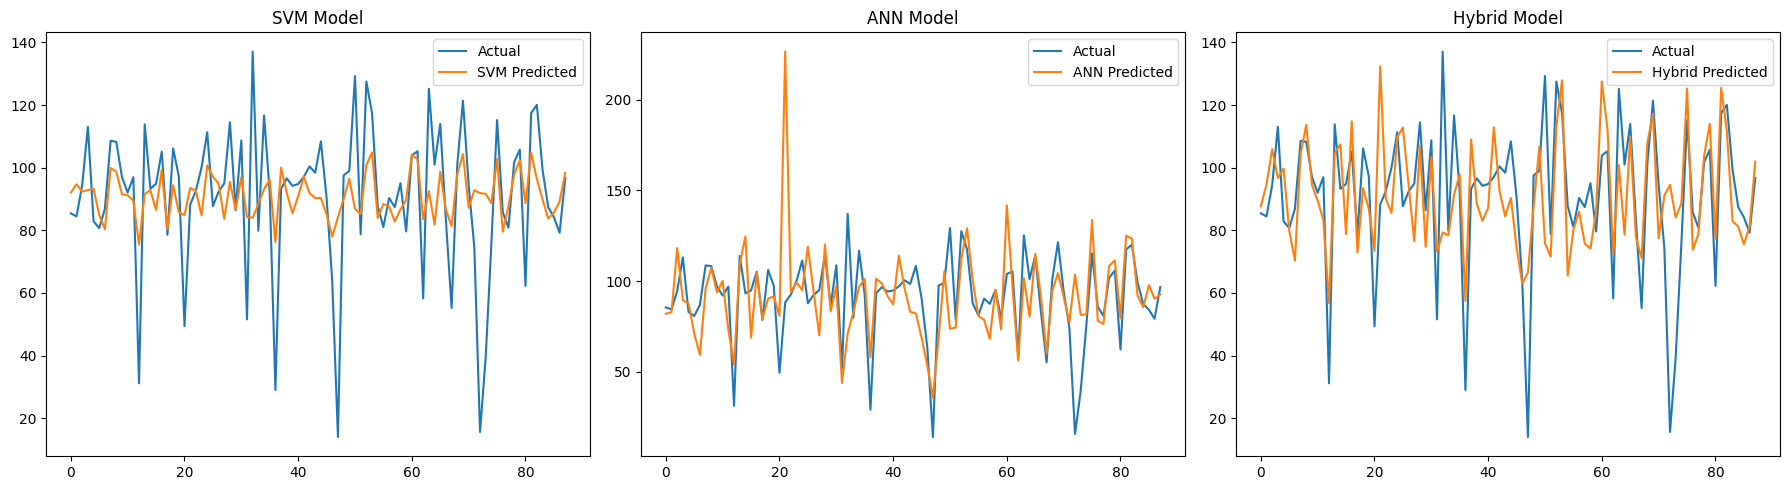

In [ ]:
plt.figure(figsize=(18, 5))

# SVM
plt.subplot(1, 3, 1)
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_svm, label='SVM Predicted')
plt.title("SVM Model")
plt.legend()

# ANN
plt.subplot(1, 3, 2)
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_ann, label='ANN Predicted')
plt.title("ANN Model")
plt.legend()

# Hybrid
plt.subplot(1, 3, 3)
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_hybrid, label='Hybrid Predicted')
plt.title("Hybrid Model")
plt.legend()

plt.tight_layout()
plt.show()


##Graph Accuracy

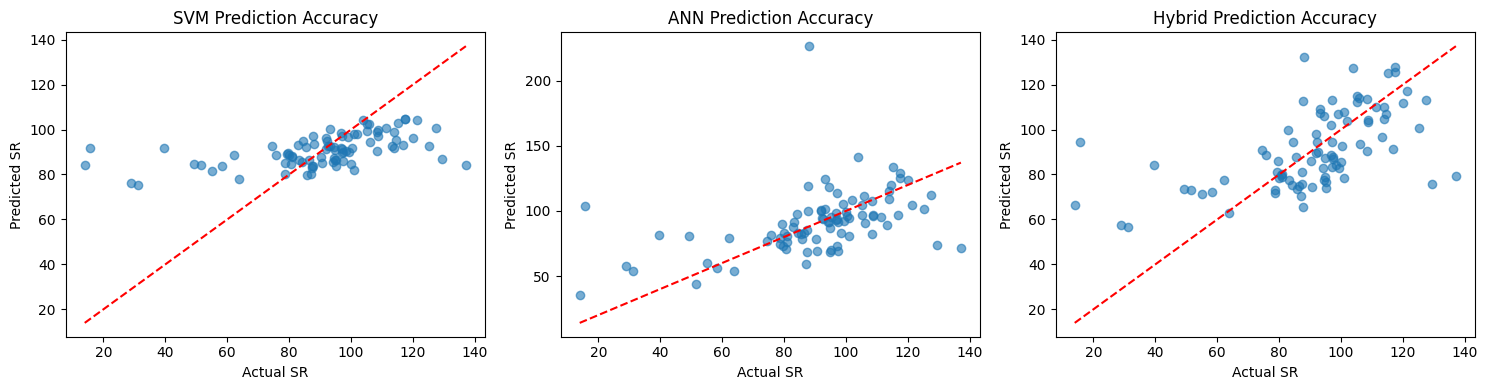

In [ ]:
plt.figure(figsize=(15, 4))

models = {
    'SVM': y_pred_svm,
    'ANN': y_pred_ann,
    'Hybrid': y_pred_hybrid
}

for i, (name, pred) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual SR")
    plt.ylabel("Predicted SR")
    plt.title(f"{name} Prediction Accuracy")

plt.tight_layout()
plt.show()


##Graph Error

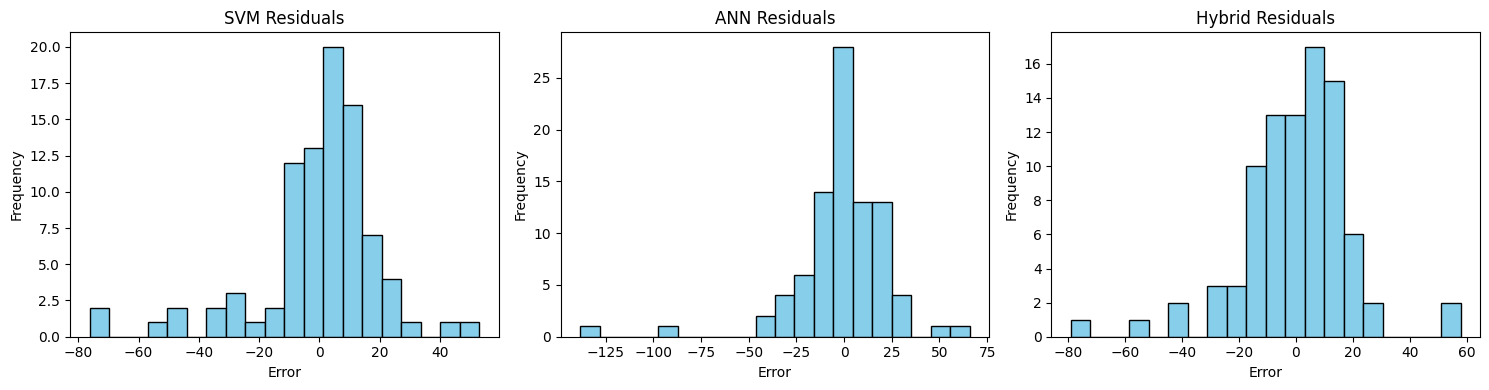

In [ ]:
plt.figure(figsize=(15, 4))

for i, (name, pred) in enumerate(models.items(), 1):
    residuals = y_test - pred
    plt.subplot(1, 3, i)
    plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
    plt.title(f"{name} Residuals")
    plt.xlabel("Error")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


##Graph Model Prediction

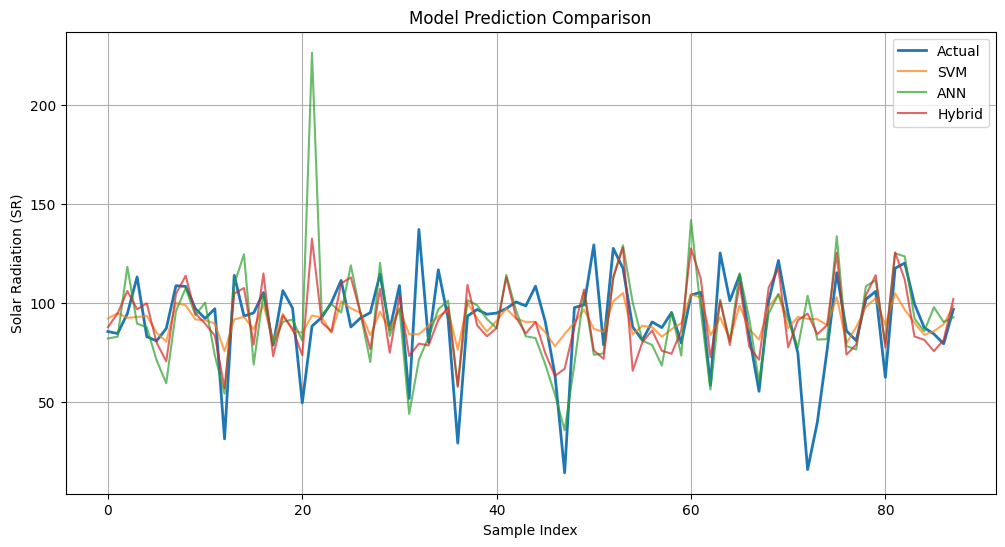

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred_svm, label='SVM', alpha=0.7)
plt.plot(y_pred_ann, label='ANN', alpha=0.7)
plt.plot(y_pred_hybrid, label='Hybrid', alpha=0.7)
plt.title("Model Prediction Comparison")
plt.xlabel("Sample Index")
plt.ylabel("Solar Radiation (SR)")
plt.legend()
plt.grid(True)
plt.show()
